In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

In [2]:
img_dir = "/kaggle/input/datasets/musfirathossain/jediidataset/JediOrganismDetectionDataset/coco_train_data/images"
ann_path = "/kaggle/input/datasets/musfirathossain/jediidataset/JediOrganismDetectionDataset/coco_train_data/coco.json"

print("Image folder exists:", os.path.exists(img_dir))
print("Annotation file exists:", os.path.exists(ann_path))

Image folder exists: True
Annotation file exists: True


In [3]:
with open(ann_path, "r") as f:
    coco = json.load(f)

print("Top-level keys:", coco.keys())
print("Number of images:", len(coco["images"]))
print("Number of annotations:", len(coco["annotations"]))
print("Number of categories:", len(coco["categories"]))

Top-level keys: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Number of images: 4864
Number of annotations: 9306
Number of categories: 20


In [4]:
categories_df = pd.DataFrame(coco["categories"])
categories_df

,supercategory,id,name
0,machine,1,machine
1,organism,2,shrimp
2,organism,3,crab
3,organism,4,squat-lobster
4,organism,5,sea-spider
5,organism,6,fish
6,organism,7,shark
7,organism,8,ray
8,organism,9,squid
9,organism,10,octopus


In [5]:
cat_id_to_name = {cat["id"]: cat["name"] for cat in coco["categories"]}
img_id_to_info = {img["id"]: img for img in coco["images"]}

print("Category mapping:")
print(cat_id_to_name)

Category mapping:
{1: 'machine', 2: 'shrimp', 3: 'crab', 4: 'squat-lobster', 5: 'sea-spider', 6: 'fish', 7: 'shark', 8: 'ray', 9: 'squid', 10: 'octopus', 11: 'coral/sea-anemone', 12: 'jellyfish', 13: 'comb-jelly', 14: 'sea-cucumber', 15: 'urchin', 16: 'starfish', 17: 'crinoid', 18: 'ragworm', 19: 'tunicate', 20: 'sponge'}


In [6]:
rows = []

for ann in coco["annotations"]:
    img_info = img_id_to_info[ann["image_id"]]
    bbox = ann["bbox"]  # [x, y, width, height]

    x_min = bbox[0]
    y_min = bbox[1]
    bbox_w = bbox[2]
    bbox_h = bbox[3]
    x_max = x_min + bbox_w
    y_max = y_min + bbox_h

    img_w = img_info["width"]
    img_h = img_info["height"]

    x_center = (x_min + bbox_w / 2) / img_w
    y_center = (y_min + bbox_h / 2) / img_h
    bbox_w_norm = bbox_w / img_w
    bbox_h_norm = bbox_h / img_h

    rows.append({
        "image_id": ann["image_id"],
        "image_name": img_info["file_name"],
        "class_id": ann["category_id"],
        "class_name": cat_id_to_name[ann["category_id"]],
        "x_min": x_min,
        "y_min": y_min,
        "x_max": x_max,
        "y_max": y_max,
        "bbox_w": bbox_w,
        "bbox_h": bbox_h,
        "img_w": img_w,
        "img_h": img_h,
        "x_center": x_center,
        "y_center": y_center,
        "bbox_w_norm": bbox_w_norm,
        "bbox_h_norm": bbox_h_norm
    })

df = pd.DataFrame(rows)
df.head()

,image_id,image_name,class_id,class_name,x_min,y_min,x_max,y_max,bbox_w,bbox_h,img_w,img_h,x_center,y_center,bbox_w_norm,bbox_h_norm
0,0,2K0262OUTUM105_120.jpg,3,crab,332,155,394,222,62,67,480,360,0.756250,0.523611,0.129167,0.186111
1,1,2K0266OUTUM1013_240.jpg,6,fish,177,150,280,177,103,27,480,360,0.476042,0.454167,0.214583,0.075000
2,2,2K0268OUTUM1010_480.jpg,6,fish,105,107,338,258,233,151,480,360,0.461458,0.506944,0.485417,0.419444
3,3,2K0268OUTUM1012_113.jpg,1,machine,264,1,480,359,216,358,480,360,0.775000,0.500000,0.450000,0.994444
4,3,2K0268OUTUM1012_113.jpg,14,sea-cucumber,169,59,420,300,251,241,480,360,0.613542,0.498611,0.522917,0.669444


In [7]:
print("Total images listed in COCO:", len(coco["images"]))
print("Total annotations:", len(df))
print("\nClass counts:")
print(df["class_name"].value_counts())

Total images listed in COCO: 4864
Total annotations: 9306

Class counts:
class_name
machine              2492
fish                 1734
coral/sea-anemone    1039
starfish             1025
crab                  592
sponge                436
sea-cucumber          416
shrimp                358
jellyfish             261
crinoid               240
squat-lobster         175
squid                 115
comb-jelly            101
octopus                96
urchin                 62
tunicate               42
sea-spider             37
shark                  37
ray                    29
ragworm                19
Name: count, dtype: int64


In [8]:
image_files = [f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
print("Total image files found in folder:", len(image_files))

Total image files found in folder: 4864


In [9]:
class_counts = df["class_name"].value_counts().sort_values(ascending=False)
class_names = class_counts.index.tolist()

base_colors = [
    "#1f77b4", "#17becf", "#e377c2", "#2ca02c", "#ff7f0e",
    "#9467bd", "#d62728", "#8c564b", "#bcbd22", "#7f7f7f"
]

class_color_map = {
    cls: base_colors[i % len(base_colors)] for i, cls in enumerate(class_names)
}

bar_colors = [class_color_map.get(cls, "#9467bd") for cls in class_counts.index]

print(class_color_map)

{'machine': '#1f77b4', 'fish': '#17becf', 'coral/sea-anemone': '#e377c2', 'starfish': '#2ca02c', 'crab': '#ff7f0e', 'sponge': '#9467bd', 'sea-cucumber': '#d62728', 'shrimp': '#8c564b', 'jellyfish': '#bcbd22', 'crinoid': '#7f7f7f', 'squat-lobster': '#1f77b4', 'squid': '#17becf', 'comb-jelly': '#e377c2', 'octopus': '#2ca02c', 'urchin': '#ff7f0e', 'tunicate': '#9467bd', 'sea-spider': '#d62728', 'shark': '#8c564b', 'ray': '#bcbd22', 'ragworm': '#7f7f7f'}


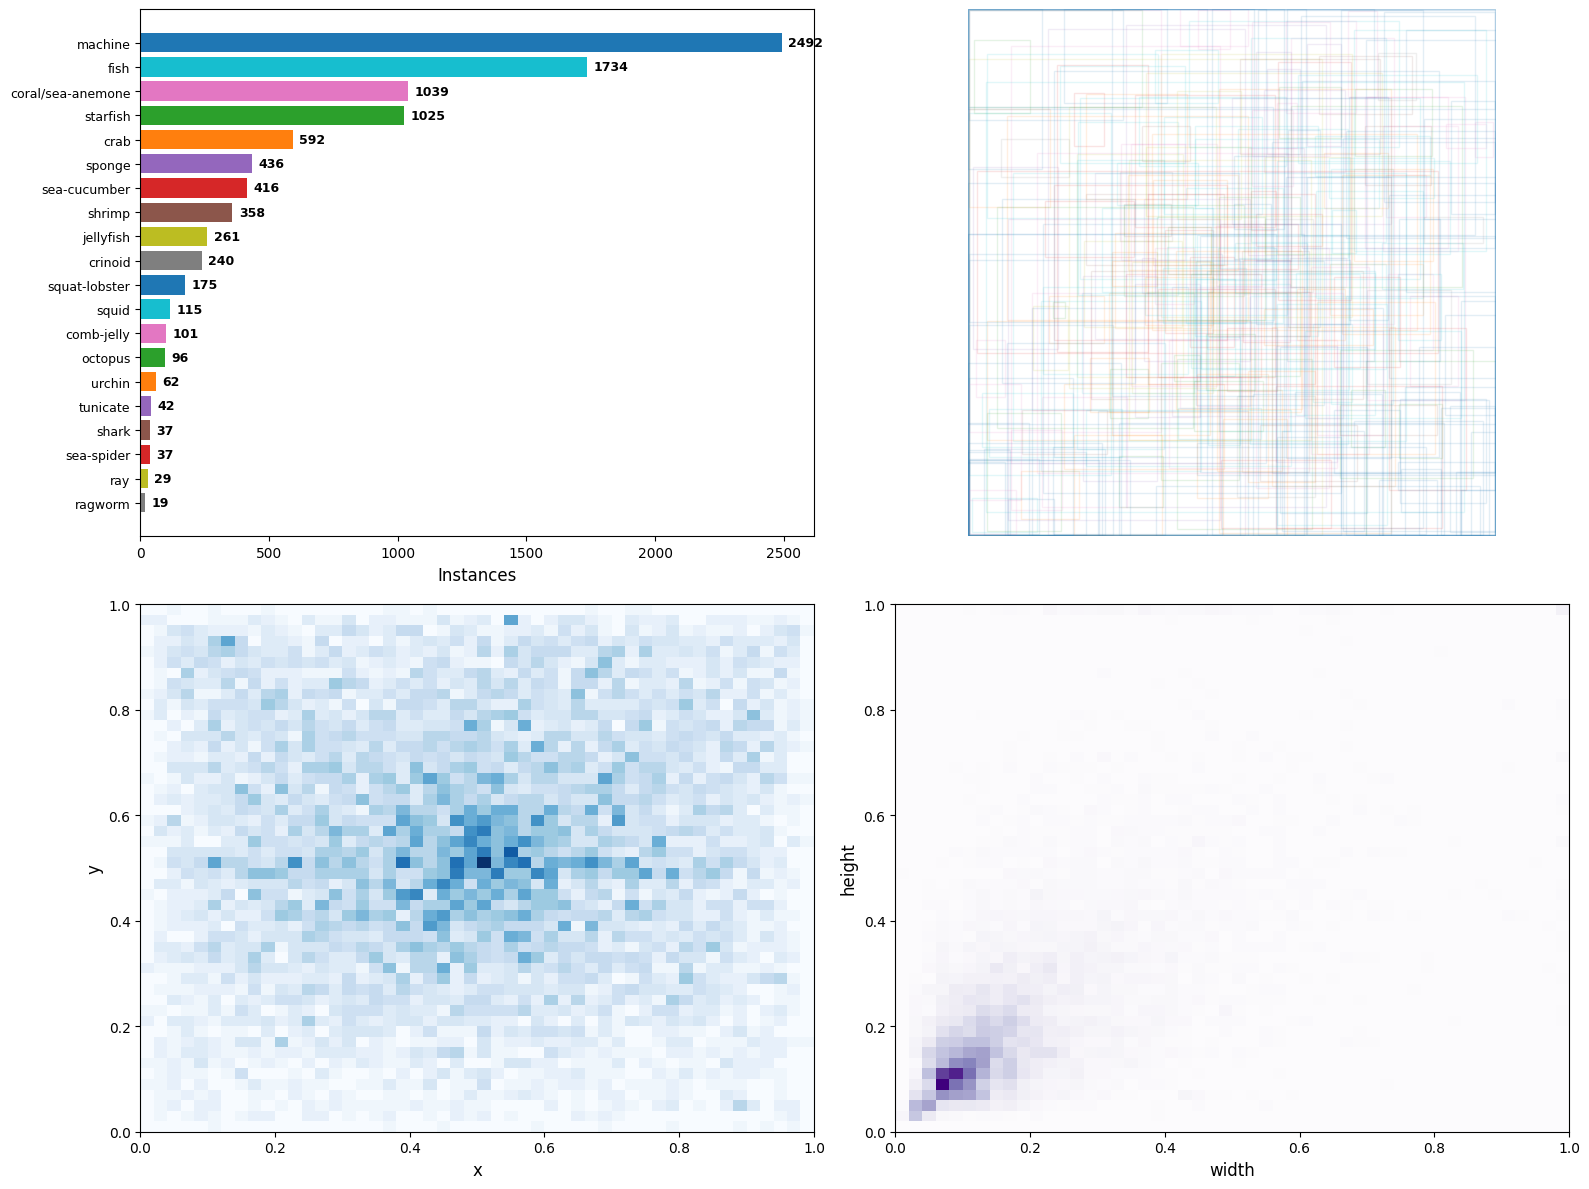

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Top-left: Class Frequency
class_counts_plot = class_counts.sort_values(ascending=True)

bars = axes[0, 0].barh(
    class_counts_plot.index,
    class_counts_plot.values,
    color=[class_color_map.get(cls, "#9467bd") for cls in class_counts_plot.index]
)

axes[0, 0].set_xlabel("Instances", fontsize=12)
axes[0, 0].tick_params(axis='y', labelsize=9)

for i, v in enumerate(class_counts_plot.values):
    axes[0, 0].text(v + max(class_counts_plot.values)*0.01, i, str(v), va="center", fontsize=9, fontweight="bold")

#Top-right: Bounding-Box Overlay
overlay_df = df.sample(min(len(df), 300), random_state=42)

for _, row in overlay_df.iterrows():
    x = row["x_center"] - row["bbox_w_norm"] / 2
    y = row["y_center"] - row["bbox_h_norm"] / 2
    cls = row["class_name"]
    color = class_color_map.get(cls, "#7f7f7f")

    rect = Rectangle(
        (x, y),
        row["bbox_w_norm"],
        row["bbox_h_norm"],
        fill=False,
        edgecolor=color,
        alpha=0.12,
        linewidth=1
    )
    axes[0, 1].add_patch(rect)

axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(1, 0)
axes[0, 1].set_aspect("equal")
axes[0, 1].axis("off")

#Bottom-left: Object-Center Distribution
axes[1, 0].hist2d(
    df["x_center"],
    df["y_center"],
    bins=50,
    range=[[0, 1], [0, 1]],
    cmap="Blues"
)
axes[1, 0].set_xlabel("x", fontsize=12)
axes[1, 0].set_ylabel("y", fontsize=12)

#Bottom-right: Width-Height Distribution
axes[1, 1].hist2d(
    df["bbox_w_norm"],
    df["bbox_h_norm"],
    bins=50,
    range=[[0, 1], [0, 1]],
    cmap="Purples"
)
axes[1, 1].set_xlabel("width", fontsize=12)
axes[1, 1].set_ylabel("height", fontsize=12)

plt.tight_layout()
plt.show()

In [11]:
save_path = "/kaggle/working/jedi_dataset_distribution_analysis.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print("Saved at:", save_path)

Saved at: /kaggle/working/jedi_dataset_distribution_analysis.png


In [12]:
print("Total images:", len(coco["images"]))
print("Total annotations:", len(df))
print("\nClass distribution:")
print(df["class_name"].value_counts())

Total images: 4864
Total annotations: 9306

Class distribution:
class_name
machine              2492
fish                 1734
coral/sea-anemone    1039
starfish             1025
crab                  592
sponge                436
sea-cucumber          416
shrimp                358
jellyfish             261
crinoid               240
squat-lobster         175
squid                 115
comb-jelly            101
octopus                96
urchin                 62
tunicate               42
sea-spider             37
shark                  37
ray                    29
ragworm                19
Name: count, dtype: int64


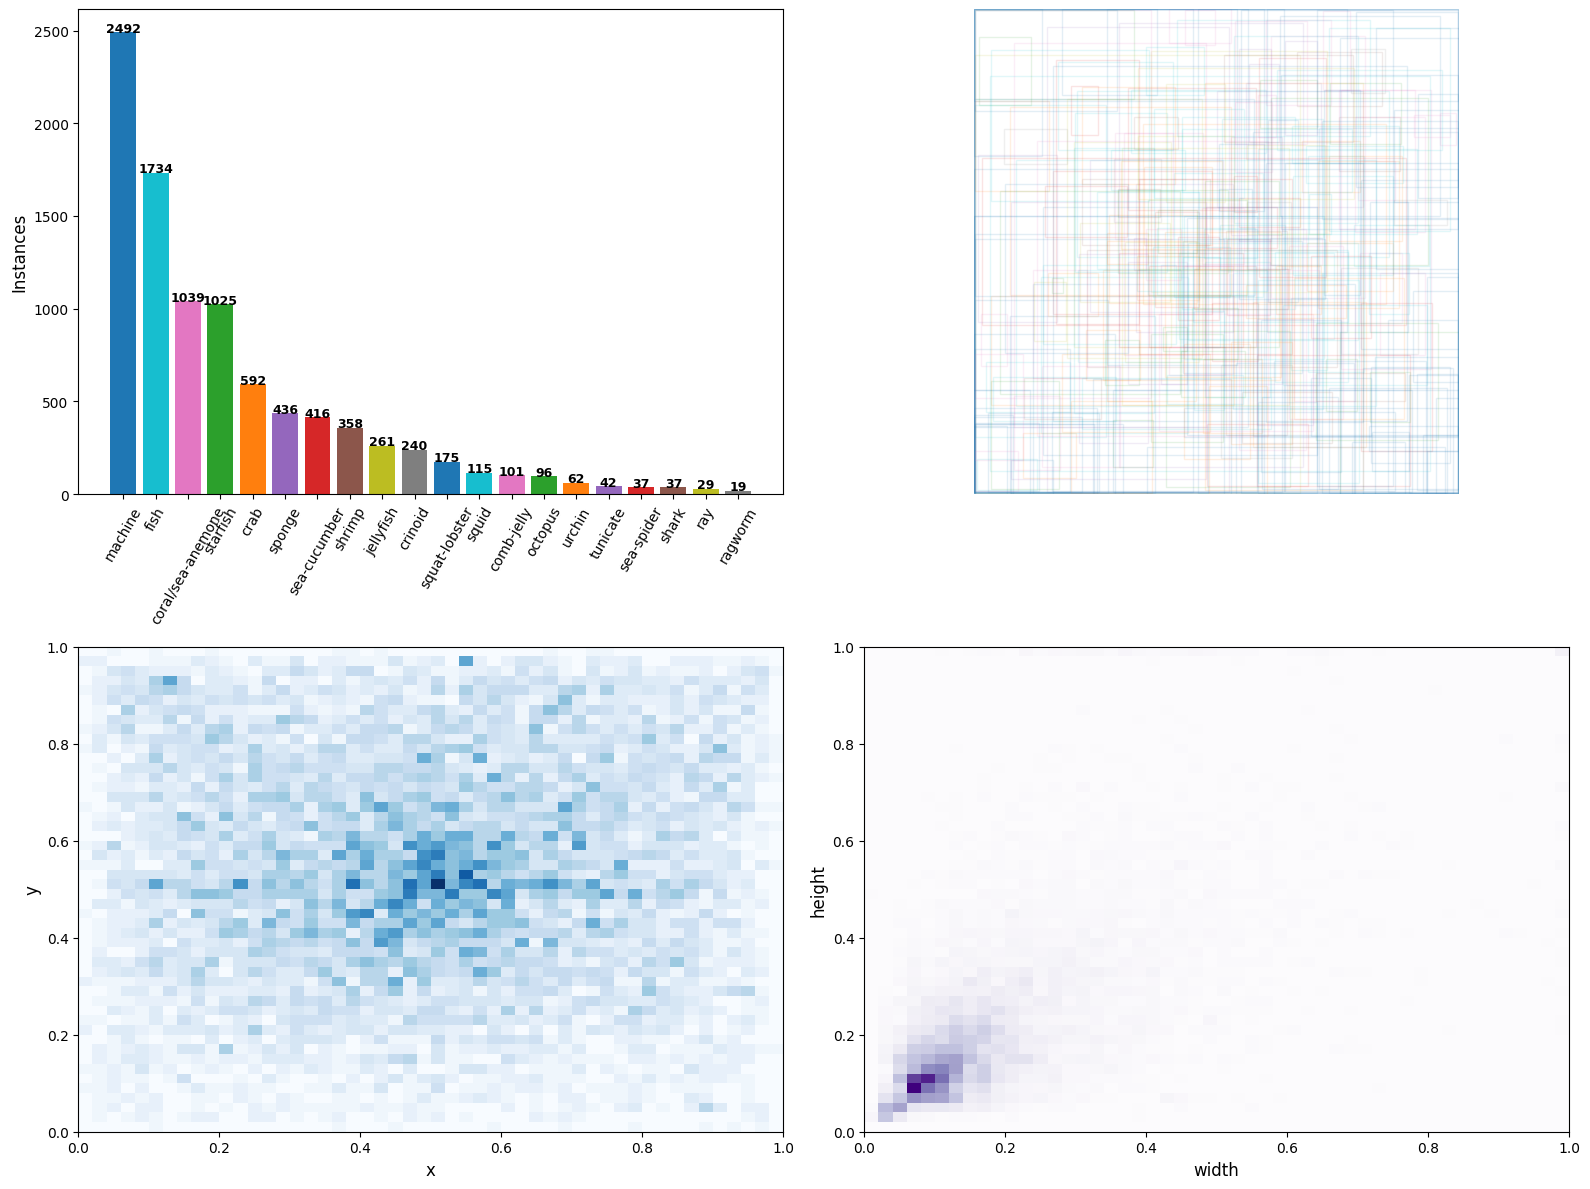

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

bars = axes[0, 0].bar(class_counts.index, class_counts.values, color=bar_colors)
axes[0, 0].set_ylabel("Instances", fontsize=12)

for i, v in enumerate(class_counts.values):
    axes[0, 0].text(i, v + 2, str(v), ha="center", fontsize=9, fontweight="bold")

axes[0, 0].tick_params(axis='x', rotation=60)

overlay_df = df.sample(min(len(df), 300), random_state=42)

for _, row in overlay_df.iterrows():
    x = row["x_center"] - row["bbox_w_norm"] / 2
    y = row["y_center"] - row["bbox_h_norm"] / 2
    cls = row["class_name"]
    color = class_color_map.get(cls, "#7f7f7f")

    rect = Rectangle(
        (x, y),
        row["bbox_w_norm"],
        row["bbox_h_norm"],
        fill=False,
        edgecolor=color,
        alpha=0.12,
        linewidth=1
    )
    axes[0, 1].add_patch(rect)

axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(1, 0)
axes[0, 1].set_aspect("equal")
axes[0, 1].axis("off")

axes[1, 0].hist2d(
    df["x_center"],
    df["y_center"],
    bins=50,
    range=[[0, 1], [0, 1]],
    cmap="Blues"
)
axes[1, 0].set_xlabel("x", fontsize=12)
axes[1, 0].set_ylabel("y", fontsize=12)

axes[1, 1].hist2d(
    df["bbox_w_norm"],
    df["bbox_h_norm"],
    bins=50,
    range=[[0, 1], [0, 1]],
    cmap="Purples"
)
axes[1, 1].set_xlabel("width", fontsize=12)
axes[1, 1].set_ylabel("height", fontsize=12)

plt.tight_layout()
plt.show()